# Aviation Accidents Analysis

You are part of a consulting firm that is tasked to do an analysis of commercial and passenger jet airline safety. The client (an airline/airplane insurer) is interested in knowing what types of aircraft (makes/models) exhibit low rates of total destruction and low likelihood of fatal or serious passenger injuries in the event of an accident. They are also interested in any general variables/conditions that might be at play. Your analysis will be based off of aviation accident data accumulated from the years 1948-2023. 

Our client is only interested in airplane makes/models that are professional builds and could potentially still be active. Assume a max lifetime of 40 years for a make/model retirement and make sure to filter your data accordingly (i.e. from 1983 onwards). They would also like separate recommendations for small aircraft vs. larger passenger models. **In addition, make sure that claims that you make are statistically robust and that you have enough samples when making comparisons between groups.**


In this summative assessment you will demonstrate your ability to:
- Use Pandas to load, inspect, and clean the dataset appropriately. 
- Transform relevant columns to create measures that address the problem at hand.
- **conduct EDA: visualization and statistical measures to understand the structure of the data**
- **recommend a set of manufacturers to consider as well as specific airplanes conforming to the client's request**
- **discuss the relationship between serious injuries/airplane damage incurred and at least *two* factors at play in the incident. You must provide supporting evidence (visuals, summary statistics, tables) for each claim you make.**

In [4]:
# loading relevant packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Exploratory Data Analysis  
- Load in the cleaned data

In [5]:
data = pd.read_csv("./data/cleaned_aviation_data.csv")
data

,Aircraft.damage,Make,Model,Number.of.Engines,Total.Fatal.Injuries,Total.Serious.Injuries,Weather.Condition,Broad.phase.of.flight,Publication.Date,is_destroyed
0,Destroyed,PIPER,PA24-180,1.0,4.0,0.0,UNK,other,1996-09-19,True
1,Destroyed,CESSNA,172M,1.0,3.0,0.0,IMC,Cruise,2007-02-26,True
2,Destroyed,ROCKWELL,112,1.0,2.0,0.0,IMC,Cruise,2000-09-12,True
3,Destroyed,CESSNA,180,1.0,4.0,0.0,IMC,other,2001-11-06,True
4,Destroyed,BELLANCA,17-30A,1.0,0.0,0.0,IMC,Cruise,1983-01-02,True
...,...,...,...,...,...,...,...,...,...,...
53532,Unknown,CESSNA,172F,NaN,0.0,1.0,NaN,NaN,2022-12-22,False
53533,Unknown,AIR TRACTOR,AT502,NaN,1.0,0.0,NaN,NaN,2022-12-28,False
53534,Unknown,PIPER,PA-28-151,NaN,0.0,1.0,NaN,NaN,2022-12-29,False
53535,Substantial,AMERICAN CHAMPION AIRCRAFT,8GCBC,1.0,0.0,0.0,VMC,NaN,2022-12-27,False


## Explore safety metrics across models/makes
- Remember that the client is interested in separate recommendations for smaller airplanes and larger airplanes. Choose a passenger threshold of 20 and separate the plane types. 

In [7]:
# data["Number.of.Engines"].value_counts()
data['Aircraft.size'] = np.where(data['Number.of.Engines'] > 2, 'large', 'small')
data

,Aircraft.damage,Make,Model,Number.of.Engines,Total.Fatal.Injuries,Total.Serious.Injuries,Weather.Condition,Broad.phase.of.flight,Publication.Date,is_destroyed,Aircraft.size
0,Destroyed,PIPER,PA24-180,1.0,4.0,0.0,UNK,other,1996-09-19,True,small
1,Destroyed,CESSNA,172M,1.0,3.0,0.0,IMC,Cruise,2007-02-26,True,small
2,Destroyed,ROCKWELL,112,1.0,2.0,0.0,IMC,Cruise,2000-09-12,True,small
3,Destroyed,CESSNA,180,1.0,4.0,0.0,IMC,other,2001-11-06,True,small
4,Destroyed,BELLANCA,17-30A,1.0,0.0,0.0,IMC,Cruise,1983-01-02,True,small
...,...,...,...,...,...,...,...,...,...,...,...
53532,Unknown,CESSNA,172F,NaN,0.0,1.0,NaN,NaN,2022-12-22,False,small
53533,Unknown,AIR TRACTOR,AT502,NaN,1.0,0.0,NaN,NaN,2022-12-28,False,small
53534,Unknown,PIPER,PA-28-151,NaN,0.0,1.0,NaN,NaN,2022-12-29,False,small
53535,Substantial,AMERICAN CHAMPION AIRCRAFT,8GCBC,1.0,0.0,0.0,VMC,NaN,2022-12-27,False,small


#### Analyzing Makes

Explore the human injury risk profile for small and larger Makes:
- choose the 15 makes for each group possessing the lowest mean fatal/seriously injured fraction
- plot the mean fatal/seriously injured fraction for each of these subgroups side-by-side

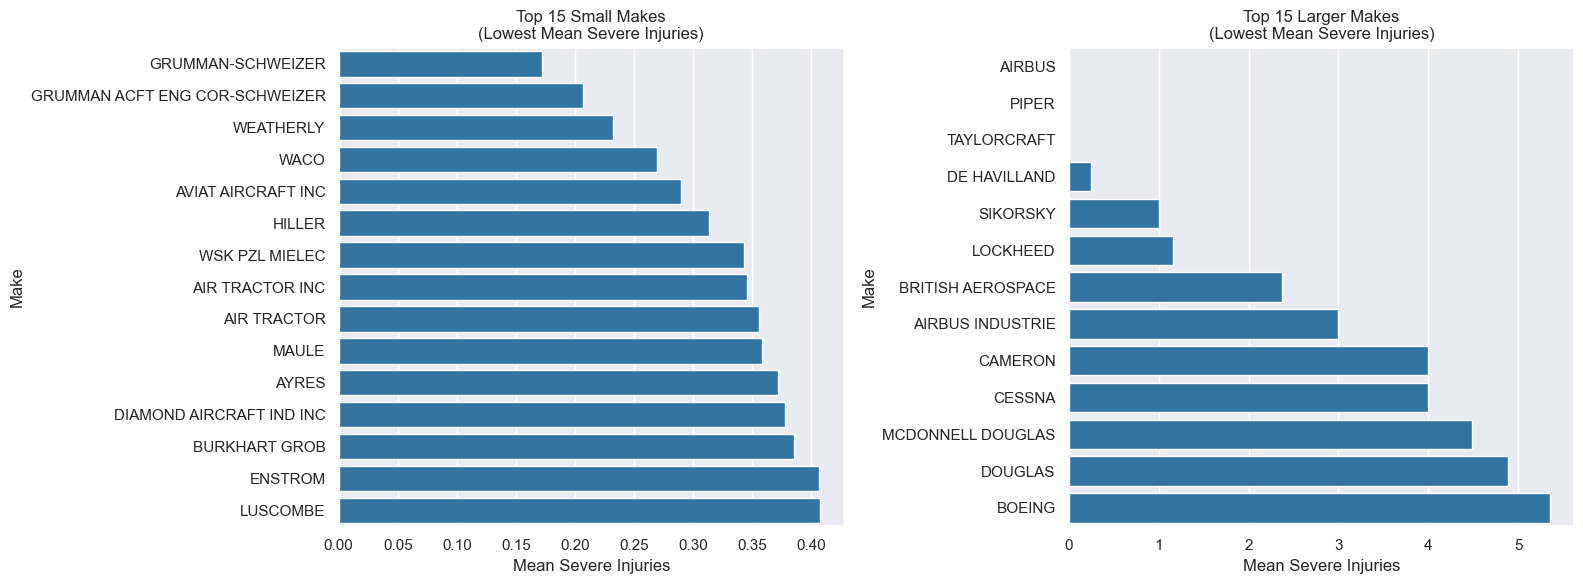

In [12]:
# Ensure that NaNs are filled
data['Total.Fatal.Injuries'] = data['Total.Fatal.Injuries'].fillna(0.0)
data['Total.Serious.Injuries'] = data['Total.Serious.Injuries'].fillna(0.0)
# Create a new injuries column
data['Severe_Injuries'] = data['Total.Fatal.Injuries'] + data['Total.Serious.Injuries']

# Get the small and large aircrafts
small_aircraft = data[data['Aircraft.size'] == 'small']
large_aircraft = data[data['Aircraft.size'] == 'large']

# Calculate the mean severe injuries per Make and grab the lowest 15
top_15_small = small_aircraft.groupby('Make')['Severe_Injuries'].mean().nsmallest(15).reset_index()
top_15_large = large_aircraft.groupby('Make')['Severe_Injuries'].mean().nsmallest(15).reset_index()

# Add a group identifier label to keep things organized for Seaborn
top_15_small['Group'] = 'Small Makes'
top_15_large['Group'] = 'Larger Makes'

# Combine them into a single clean plotting DataFrame
combined_df = pd.concat([top_15_small, top_15_large])

# LET'S PLOT:
sns.set_context("notebook")
sns.set_style("darkgrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharex=False)

# Plot Small Makes on the left canvas
sns.barplot(
    data=top_15_small, 
    y='Make', 
    x='Severe_Injuries', 
    ax=axes[0], 
)
axes[0].set(title="Top 15 Small Makes\n(Lowest Mean Severe Injuries)", xlabel="Mean Severe Injuries")

# Plot Large Makes on the right canvas
sns.barplot(
    data=top_15_large, 
    y='Make', 
    x='Severe_Injuries', 
    ax=axes[1], 
)
axes[1].set(title="Top 15 Larger Makes\n(Lowest Mean Severe Injuries)", xlabel="Mean Severe Injuries")

plt.tight_layout()
plt.show()

**Distribution of injury rates: small makes**

Use a violinplot to look at the distribution of the fraction of passengers serious/fatally injured for small airplane makes. Just display makes with the ten lowest mean serious/fatal injury rates.

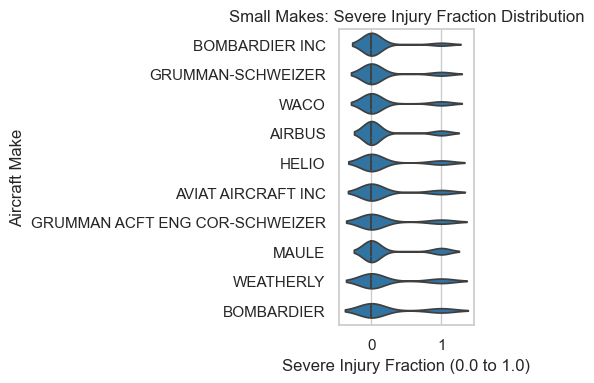

In [ ]:
# Calculate total injuries per incident
injuries = data['Severe_Injuries'] # Created this column in the previous step

# Calculate the fraction into a new column
data['Injury_Fraction'] = np.where(injuries > 0, 
                                   (data['Total.Fatal.Injuries'] + data['Total.Serious.Injuries']) / injuries, 
                                   0)

# Find the specific names of the 10 safest makes (lowest means), re-use small/large_aircraft
safest_small_makes = small_aircraft.groupby('Make')['Injury_Fraction'].mean().nsmallest(10).index
safest_large_makes = large_aircraft.groupby('Make')['Injury_Fraction'].mean().nsmallest(10).index

# Filter the raw dataframes to only include those specific safe makes
plot_data_small = small_aircraft[small_aircraft['Make'].isin(safest_small_makes)]
plot_data_large = large_aircraft[large_aircraft['Make'].isin(safest_large_makes)]

#START PLOTTING
plt.figure(figsize=(5, 4))

sns.violinplot(
    data=plot_data_small,
    y='Make',
    x='Injury_Fraction',
    order=safest_small_makes,
    inner='quartile'
)

plt.title("Small Makes: Severe Injury Fraction Distribution")
plt.xlabel("Severe Injury Fraction (0.0 to 1.0)")
plt.ylabel("Aircraft Make")

plt.tight_layout()
plt.show()

**Distribution of injury rates: large makes**

Use a stripplot to look at the distribution of the fraction of passengers serious/fatally injured for large airplane makes. Just display makes with the ten lowest mean serious/fatal injury rates.

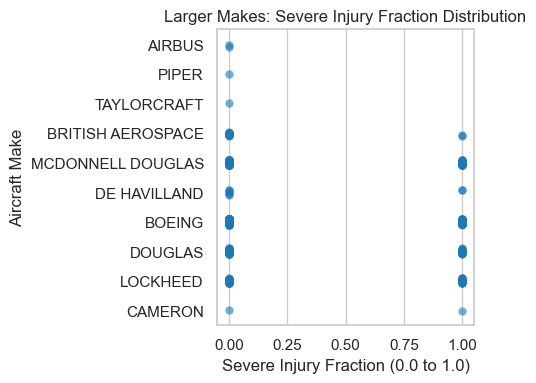

In [29]:
#USING THE DATING CALCULATED PREVIOUSLY
plt.figure(figsize=(5, 4))

sns.stripplot(
    data=plot_data_large,
    y='Make',
    x='Injury_Fraction',
    order=safest_large_makes,
    size=6,                   
    alpha=0.6,                
    jitter=True               
)

plt.title("Larger Makes: Severe Injury Fraction Distribution")
plt.xlabel("Severe Injury Fraction (0.0 to 1.0)")
plt.ylabel("Aircraft Make")

plt.tight_layout()
plt.show()

**Evaluate the rate of aircraft destruction for both small and large aircraft by Make.** 

Sort your results and keep the lowest 15.

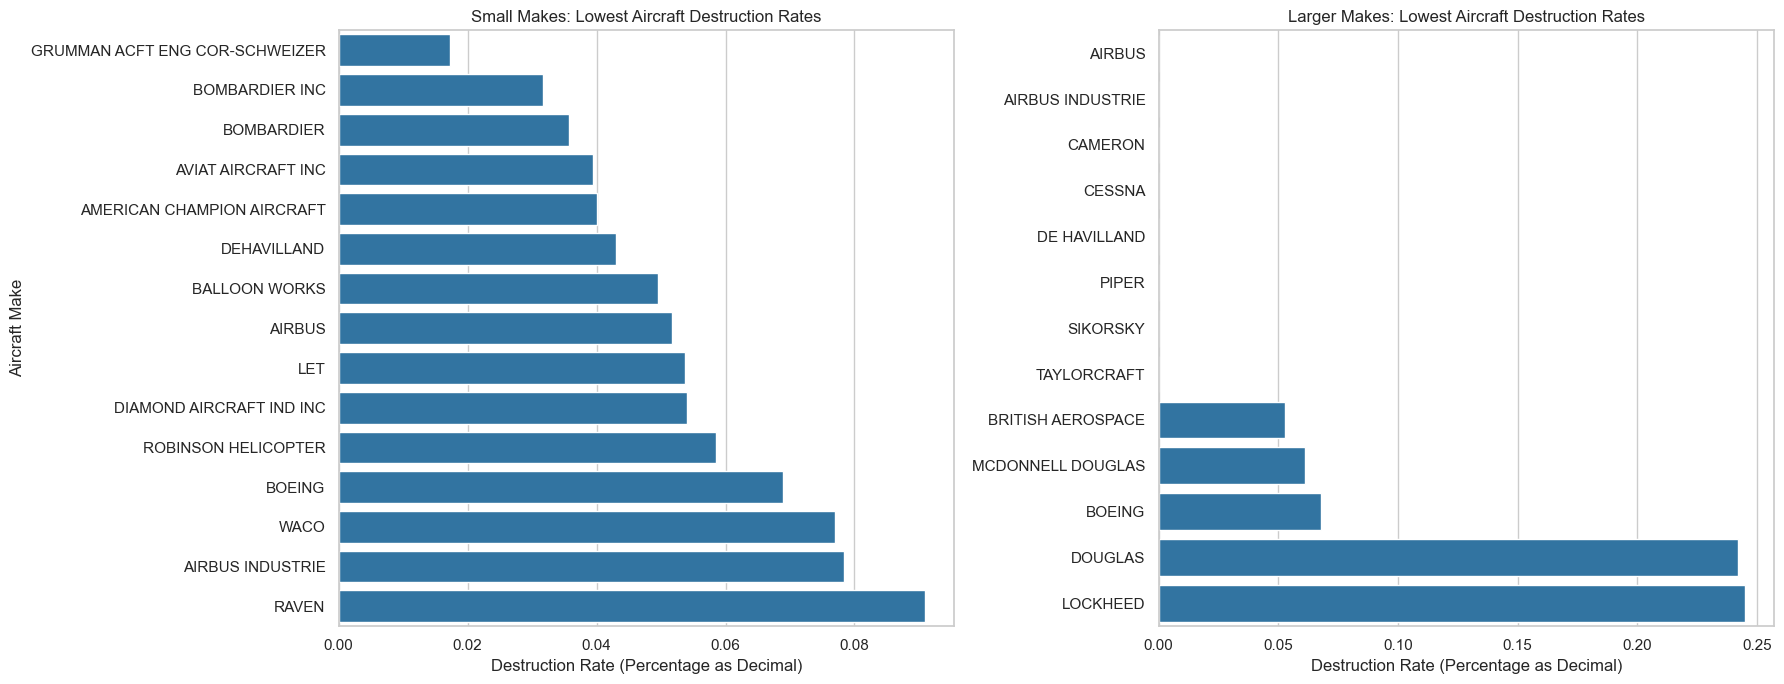

In [30]:
# Calculate the mean destruction rate per Make and pull the 15 lowest values (re-use small/large_aircraft)
lowest_destruction_small = small_aircraft.groupby('Make')['is_destroyed'].mean().nsmallest(15).reset_index()
lowest_destruction_large = large_aircraft.groupby('Make')['is_destroyed'].mean().nsmallest(15).reset_index()

# Create a dual-canvas layout frame
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Plot 1: Small Aircraft Destruction Rates
sns.barplot(
    data=lowest_destruction_small,
    x='is_destroyed',
    y='Make',
    ax=axes[0],
)
axes[0].set(
    title="Small Makes: Lowest Aircraft Destruction Rates",
    xlabel="Destruction Rate (Percentage as Decimal)",
    ylabel="Aircraft Make"
)

# Plot 2: Large Aircraft Destruction Rates
sns.barplot(
    data=lowest_destruction_large,
    x='is_destroyed',
    y='Make',
    ax=axes[1],
)
axes[1].set(
    title="Larger Makes: Lowest Aircraft Destruction Rates",
    xlabel="Destruction Rate (Percentage as Decimal)",
    ylabel=""
)

plt.tight_layout()
plt.show()

#### Provide a short discussion on your findings for your summary statistics and plots:
- Make any recommendations for Makes here based off of the destroyed fraction and fraction fatally/seriously injured
- Comment on the calculated statistics and any corresponding distributions you have visualized.

In [ ]:
'''
What I Learned From the Plots:

#1. Small Planes vs. Big Planes are Completely Different
- Small Planes: Accidents here are all over the place. As we see in the violin plot, the injury rates smoothly stretch from 0% all the way to 100%. 
I believe this is because small planes fly in crazy weather, land on grass strips, and have a wide mix of minor bumps versus bad crashes.
- Big Planes: The strip plot shows a crazy binary split. The dots are crowded at exactly 0% or exactly 100% injury rates, with total empty air in the middle. 
Big commercial planes are built so well that normal accidents result in zero injuries. But if something goes wrong, it unfortunately tends to be a total loss.

#2. The Total Destruction Stats
- A bunch of the big manufacturers (like Airbus and Boeing) have a 0.0 hull destruction rate in the chart. 
That means their safety engineering team is doing their job to build a plane that stays intact.
- Older names like Douglas and Lockheed have destruction rates closer to 25%. It shows how much safer 
modern plane manufacturing has gotten over the decades.

My Recommendations for the Client:
If we are picking the safest brands based on our data...
- For Big/Commercial Planes: Go withAirbus. They have a perfect 0% destruction rate and their accident dots stay crowded at the safest 0% injury mark better than anyone else.
- For Small Planes: Go with Grumman- Schweizer. They crushed both charts, keeping their destruction rate under 2% and having the lowest average injury score by far.
'''

### Analyze plane types
- plot the mean fatal/seriously injured fraction for both small and larger planes 
- also provide a distributional plot of your choice for the fatal/seriously injured fraction by airplane type (stripplot, violin, etc)  
- filter ensuring that you have at least ten individual examples in each model/make to average over

**Larger planes**

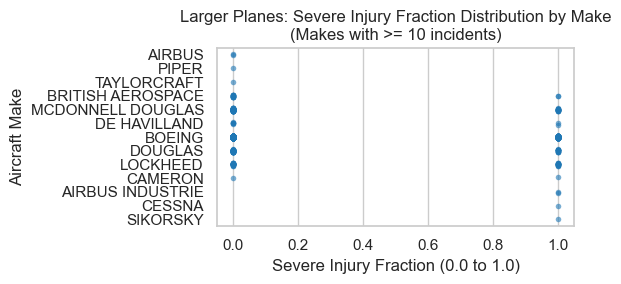

In [34]:
# Find makes with at least 10 data points and filter the main dataset
make_counts = data['Make'].value_counts()
valid_makes = make_counts[make_counts >= 10].index
filtered_data = data[data['Make'].isin(valid_makes)].copy()

# Sort the makes automatically by their average injury rate so the graph looks clean
large_makes_order = large_aircraft.groupby('Make')['Injury_Fraction'].mean().sort_values().index

plt.figure(figsize=(6, 3))

sns.stripplot(
    data=large_aircraft,
    y='Make',
    x='Injury_Fraction',
    order=large_makes_order,
    size=4,
    alpha=0.6,
    jitter=True
)

plt.title("Larger Planes: Severe Injury Fraction Distribution by Make\n(Makes with >= 10 incidents)")
plt.xlabel("Severe Injury Fraction (0.0 to 1.0)")
plt.ylabel("Aircraft Make")

plt.tight_layout()
plt.show()

**Smaller planes**
- for smaller planes, limit your plotted results to the makes with the 10 lowest mean serious/fatal injury fractions

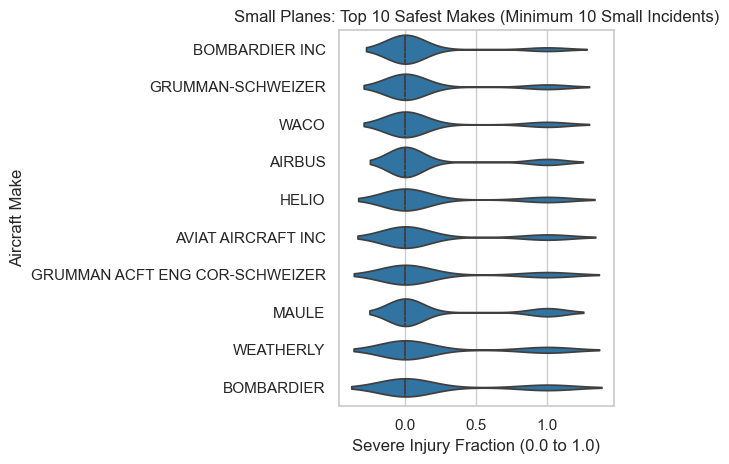

In [36]:
#  FIX: Find makes that have at least 10 incidents within the SMALL category specifically
small_make_counts = small_aircraft['Make'].value_counts()
valid_small_makes = small_make_counts[small_make_counts >= 10].index
filtered_small_planes = small_aircraft[small_aircraft['Make'].isin(valid_small_makes)]

# Now find the 10 safest makes out of these truly high-sample manufacturers
safest_small_makes = filtered_small_planes.groupby('Make')['Injury_Fraction'].mean().nsmallest(10).index

# Filter to just those top 10
plot_data_small = filtered_small_planes[filtered_small_planes['Make'].isin(safest_small_makes)]

sns.violinplot(
    data=plot_data_small,
    y='Make',
    x='Injury_Fraction',
    order=safest_small_makes,
    inner='quartile'
)

plt.title("Small Planes: Top 10 Safest Makes (Minimum 10 Small Incidents)")
plt.xlabel("Severe Injury Fraction (0.0 to 1.0)")
plt.ylabel("Aircraft Make")

plt.tight_layout()
plt.show()

### Discussion of Specific Airplane Types
- Discuss what you have found above regarding passenger fraction seriously/ both small and large airplane models.

In [ ]:
'''
LARGER PLANES
  1. The Dots Don't Lie: Every single manufacturer has their data points at exactly 0.0 or exactly 1.0. 
  There is practically nothing in the middle.
  2. For big planes, safety systems are so good that if there is an accident, the engineering usually 
  completely protects everyone. But when an accident is a major disaster, it switches to a high-severity event (dots at 1.0). 
  There is no middle ground.

SMALLER PLANES
  1. The Big Bulge at Zero: Every single one of these top 10 safe makes has a fat, wide "belly" sitting right on 0.0. 
  That means the vast majority of their accidents result in zero severe injuries. Passengers are walking away safe.
  2. Unlike the large planes, these violins have smooth, continuous necks that stretch out past 0.5 all the way to 1.0.
  3. Small planes don't have a straight split. They fly lower, slower, and land in wilder places (like fields or grass strips), 
  their accidents are mixed. A bad landing might cause a broken bone or severe injury for just one person on board, 
  which creates those middle-ground decimal numbers (0.2 to 0.7) that we don't see in commercial jets.

SUMMARY
Big planes are perfectly binary—they either protect everyone completely or it's a bad day. On the other hand, the safest small planes 
are amazing at keeping people safe, but their accidents represent a sliding scale of risk rather than an all-or-nothing flip.
'''

### Exploring Other Variables
- Investigate how other variables effect aircraft damage and injury. You must choose **two** factors out of the following but are free to analyze more:

- Weather Condition
- Engine Type
- Number of Engines
- Phase of Flight
- Purpose of Flight

For each factor provide a discussion explaining your analysis with appropriate visualization / data summaries and interpreting your findings.